# Rolling Spike Detection Comparison

This notebook compares three models — **XGBoost**, **Isolation Forest**, and **Prophet** — using a rolling window approach for detecting spikes (fee > 5 sats/vByte).

## Objective
Forecast or classify whether a spike occurs in the next 24 hours using different techniques:
- Supervised classification (XGBoost)
- Unsupervised anomaly detection (Isolation Forest)
- Forecasting-based anomaly flagging (Prophet)


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from prophet import Prophet

In [29]:
# Load and preprocess
df = pd.read_parquet("../data/processed/preprocessed_prophet.parquet").sort_index()
df["target"] = (df["recommended_fee_fastestFee"].shift(-288) > 5).astype(int)

lags = [1, 3, 6, 12, 24, 48, 96, 144, 288]
for lag in lags:
    df[f"lag_{lag}"] = df["recommended_fee_fastestFee"].shift(lag)

exog_cols = [c for c in df.columns if c.startswith("mempool") or "block" in c]
df = df.dropna()

In [30]:
# Setup
window = 288
horizon = 288
step = 144
features = [f"lag_{lag}" for lag in lags] + exog_cols

split_idx = int(len(df) * 0.8)
train_base = df.iloc[:split_idx]
test_rolling = df.iloc[split_idx:]

In [31]:
# XGBoost tuning
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
grid = {"max_depth": [3, 5], "learning_rate": [0.05, 0.1], "n_estimators": [50, 100]}
gs = GridSearchCV(xgb, grid, cv=3)
gs.fit(train_base[features], train_base["target"])
xgb_best = gs.best_estimator_

c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:31:47] WARNING: D:\bld\xgboost-split_1747336820434\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:31:48] WARNING: D:\bld\xgboost-split_1747336820434\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:31:48] WARNING: D:\bld\xgboost-split_1747336820434\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:31:48] WARNING: D:\bld\xgboost-split_1747336820434\work\src\learner.cc:738: 
Parameters:

In [32]:
# Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(train_base[features])

IsolationForest(contamination=0.05, random_state=42)

In [33]:
# Prophet base
prophet_base = df[["recommended_fee_fastestFee"]].reset_index().rename(columns={"timestamp": "ds", "recommended_fee_fastestFee": "y"})
prophet_model = Prophet()
prophet_model.fit(prophet_base.iloc[:split_idx])

12:31:51 - cmdstanpy - INFO - Chain [1] start processing
12:31:51 - cmdstanpy - INFO - Chain [1] done processing


In [34]:
# Rolling Evaluation
results = []

for start in range(0, len(test_rolling) - window - horizon, step):
    roll_train = test_rolling.iloc[start:start + window]
    roll_test = test_rolling.iloc[start + window:start + window + horizon]

    # XGBoost
    xgb_best.fit(roll_train[features], roll_train["target"])
    pred_xgb = xgb_best.predict(roll_test[features])

    # Isolation Forest
    pred_iso = iso.predict(roll_test[features])
    pred_iso = (pred_iso == -1).astype(int)

    # Prophet
    prophet_slice = pd.concat([roll_train, roll_test])[["recommended_fee_fastestFee"]].reset_index()
    prophet_slice.columns = ["ds", "y"]
    p_model = Prophet()
    p_model.fit(prophet_slice.iloc[:window])
    future = p_model.make_future_dataframe(periods=horizon, freq="5min")
    forecast = p_model.predict(future)
    upper = forecast["yhat_upper"][-horizon:].values
    actual = roll_test["recommended_fee_fastestFee"].values
    pred_prophet = (actual > upper).astype(int)

    for name, preds in zip(["XGBoost", "IsolationForest", "Prophet"], [pred_xgb, pred_iso, pred_prophet]):
        results.append({
            "model": name,
            "start": roll_test.index[0],
            "precision": precision_score(roll_test["target"], preds, zero_division=0),
            "recall": recall_score(roll_test["target"], preds, zero_division=0),
            "f1": f1_score(roll_test["target"], preds, zero_division=0)
        })
results

c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:31:51] WARNING: D:\bld\xgboost-split_1747336820434\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
12:31:51 - cmdstanpy - INFO - Chain [1] start processing
12:31:51 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:31:51] WARNING: D:\bld\xgboost-split_1747336820434\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
12:31:51 - cmdstanpy - INFO - Chain [1] start processing
12:31:51 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:31:52] WARNING: D:\bld\xgboost-split_1747336820434\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst

[{'model': 'XGBoost',
  'start': Timestamp('2025-05-02 16:15:00'),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0},
 {'model': 'IsolationForest',
  'start': Timestamp('2025-05-02 16:15:00'),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0},
 {'model': 'Prophet',
  'start': Timestamp('2025-05-02 16:15:00'),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0},
 {'model': 'XGBoost',
  'start': Timestamp('2025-05-04 04:15:00'),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0},
 {'model': 'IsolationForest',
  'start': Timestamp('2025-05-04 04:15:00'),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0},
 {'model': 'Prophet',
  'start': Timestamp('2025-05-04 04:15:00'),
  'precision': 0.23076923076923078,
  'recall': 0.6666666666666666,
  'f1': 0.34285714285714286},
 {'model': 'XGBoost',
  'start': Timestamp('2025-05-05 16:15:00'),
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0},
 {'model': 'IsolationForest',
  'start': Timestamp('2025-05-05 16:15:00'),
  'precision': 0.0,
  'recall': 0.0,

In [35]:
# Summarize
summary = pd.DataFrame(results)
avg = summary.groupby("model")[["precision", "recall", "f1"]].mean().reset_index()
print(avg)

             model  precision    recall        f1
0  IsolationForest   0.000000  0.000000  0.000000
1          Prophet   0.210575  0.421917  0.267146
2          XGBoost   0.028571  0.006897  0.011111


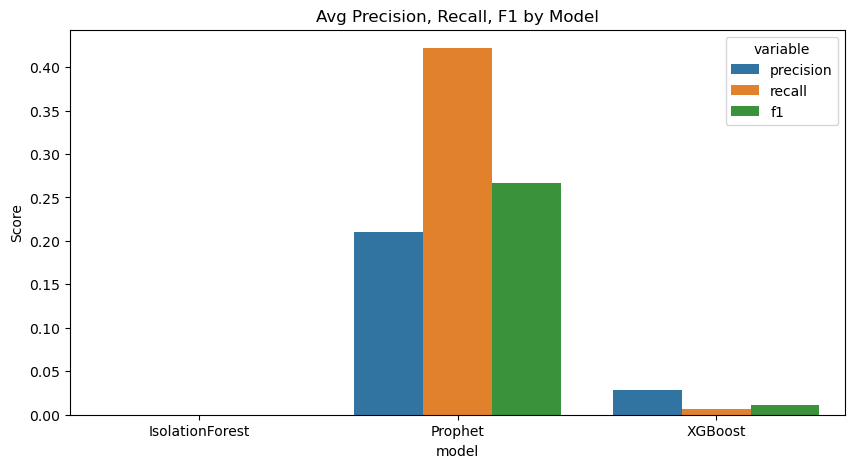

In [36]:
# Visualize
plt.figure(figsize=(10, 5))
sns.barplot(data=avg.melt(id_vars="model"), x="model", y="value", hue="variable")
plt.title("Avg Precision, Recall, F1 by Model")
plt.ylabel("Score")
plt.show()